In [1]:
pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 8.0 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=61d91225a762705e075d083c1467c67d68b1a2ae1ede10320c7eb8087c7a277c
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc


In [2]:
!pip install qiskit==1.4.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 47.0 MB/s eta 0:00:00
  Attempting uninstall: qiskit
    Found existing installation: qiskit 2.0.0
    Uninstalling qiskit-2.0.0:
      Successfully uninstalled qiskit-2.0.0


In [3]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("/content/Train_data.csv") #give the right path
df.columns
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# List of categorical columns to encode (excluding 'service' since we're dropping it)
categorical_columns = ['protocol_type', 'flag', 'class']


# Apply label encoding
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
numerical_columns =['src_bytes',
'dst_bytes',
'count',
'same_srv_rate',
'diff_srv_rate',
'dst_host_srv_count',
'dst_host_same_srv_rate',
'dst_host_same_src_port_rate']


# Scale only the numerical columns
scaler = StandardScaler()
df=df[numerical_columns + categorical_columns]

print(df.head())

   src_bytes  dst_bytes  count  same_srv_rate  diff_srv_rate  \
0        491          0      2           1.00           0.00   
1        146          0     13           0.08           0.15   
2          0          0    123           0.05           0.07   
3        232       8153      5           1.00           0.00   
4        199        420     30           1.00           0.00   

   dst_host_srv_count  dst_host_same_srv_rate  dst_host_same_src_port_rate  \
0                  25                    0.17                         0.17   
1                   1                    0.00                         0.88   
2                  26                    0.10                         0.00   
3                 255                    1.00                         0.03   
4                 255                    1.00                         0.00   

   protocol_type  flag  class  
0              1     9      1  
1              2     9      1  
2              1     5      0  
3              1  

In [5]:
from sklearn.model_selection import train_test_split
features = numerical_columns + [col for col in categorical_columns if col != 'class']
train_features, test_features, train_labels, test_labels = train_test_split(
    df[features], df['class'], train_size=0.80, random_state=42
)

In [6]:
train_features[numerical_columns] = scaler.fit_transform(train_features[numerical_columns])
test_features[numerical_columns] = scaler.transform(test_features[numerical_columns])

In [7]:
import numpy as np

train_features = np.array(train_features)
train_labels = np.array(train_labels)
test_features = np.array(test_features)
test_labels = np.array(test_labels)
len(train_features)

20153

In [14]:
num_qubits = 10
tau = 500
C = 1500

In [15]:
from qiskit.circuit.library import ZFeatureMap
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.kernels import FidelityQuantumKernel

from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)

algorithm_globals.random_seed =42

feature_map = ZFeatureMap(feature_dimension=num_qubits, reps=4)

qkernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

In [16]:
from qiskit_machine_learning.algorithms import PegasosQSVC
pegasos_qsvc = PegasosQSVC(quantum_kernel=qkernel, C=C, num_steps=tau)
pegasos_qsvc.fit(train_features, train_labels)

In [17]:
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_test_samples = len(test_features)
num_batches = 5
batch_size = num_test_samples // num_batches

scores = []
f1_scores = []
all_preds = []
all_labels = []

for i in range(num_batches):
    start_idx = i * batch_size
    end_idx = (i + 1) * batch_size

    test_subset = test_features[start_idx:end_idx]
    label_subset = test_labels[start_idx:end_idx]

    preds = pegasos_qsvc.predict(test_subset)
    preds = np.array(preds).astype(int)
    label_subset = np.array(label_subset).astype(int)

    acc = accuracy_score(label_subset, preds)
    f1 = f1_score(label_subset, preds, average='binary')

    scores.append(acc)
    f1_scores.append(f1)
    all_preds.extend(preds)
    all_labels.extend(label_subset)

    print(f"Batch {i+1}/{num_batches} - Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")
average_score = np.mean(scores)
print(f"\nPegasosQSVC Average Test Accuracy (Batch-wise): {average_score:.4f}")

Batch 1/5 - Accuracy: 0.9513, F1 Score: 0.9550
Batch 2/5 - Accuracy: 0.9295, F1 Score: 0.9341
Batch 3/5 - Accuracy: 0.9494, F1 Score: 0.9533
Batch 4/5 - Accuracy: 0.9503, F1 Score: 0.9545
Batch 5/5 - Accuracy: 0.9414, F1 Score: 0.9451

PegasosQSVC Average Test Accuracy (Batch-wise): 0.9444


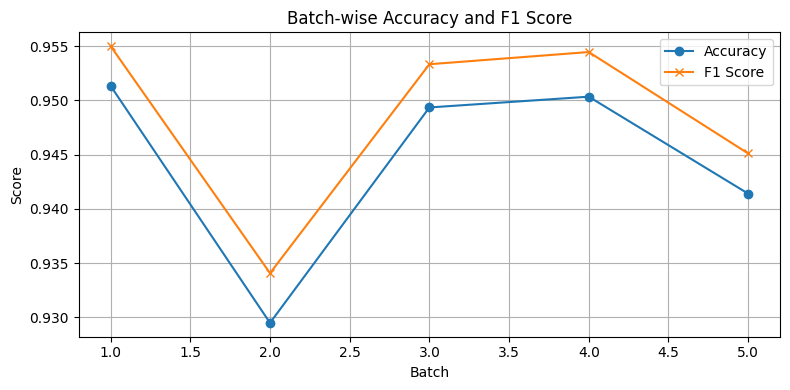

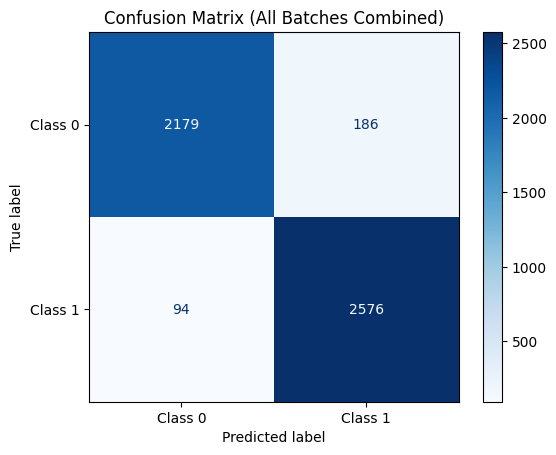

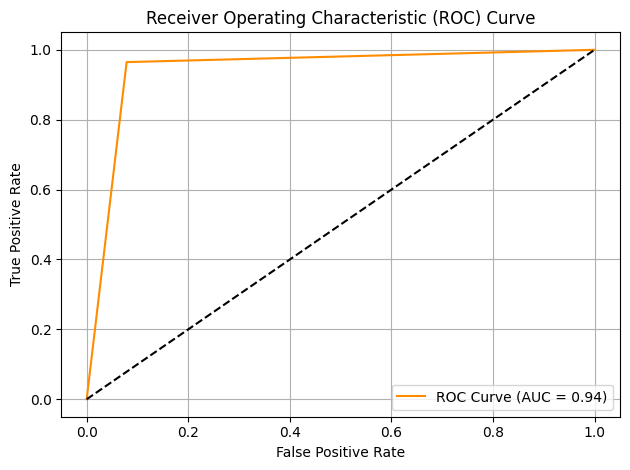

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_batches + 1), scores, marker='o', label='Accuracy')
plt.plot(range(1, num_batches + 1), f1_scores, marker='x', label='F1 Score')
plt.title("Batch-wise Accuracy and F1 Score")
plt.xlabel("Batch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (All Batches Combined)")
plt.show()

# ---- ROC Curve ----
fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

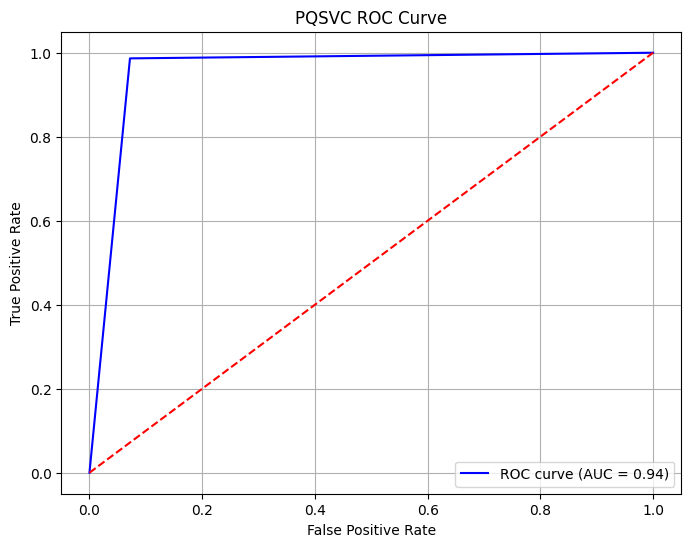

In [ ]:
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
svc = SVC(kernel='rbf', C=0.8, gamma='scale')  # You can tune C and gamma
svc.fit(train_features, train_labels)

# Predictions
predictions = svc.predict(test_features)
fpr, tpr, _ = roc_curve(test_labels, predictions)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = 0.94)')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PQSVC ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def plot_decision_boundary(X, y, model):
    h = .02  # Step size for meshgrid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="coolwarm", edgecolor="k")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("SVM Decision Boundary")
    plt.show()

plot_decision_boundary(test_features, test_labels, svc)

ValueError: X has 2 features, but SVC is expecting 10 features as input.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
pqsvc_acc = 0.9386
rf_clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_clf.fit(train_features, train_labels)
test_predictions = rf_clf.predict(test_features)
rf_accuracy = accuracy_score(test_labels, test_predictions)
print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")

Random Forest Test Accuracy: 0.9978


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
xgb_clf = XGBClassifier(n_estimators=25, learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False, eval_metric="logloss")
xgb_clf.fit(train_features, train_labels)
test_predictions = xgb_clf.predict(test_features)
xgb_accuracy = accuracy_score(test_labels, test_predictions)
print(f"XGBoost Test Accuracy: {xgb_accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:35:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Test Accuracy: 0.9855


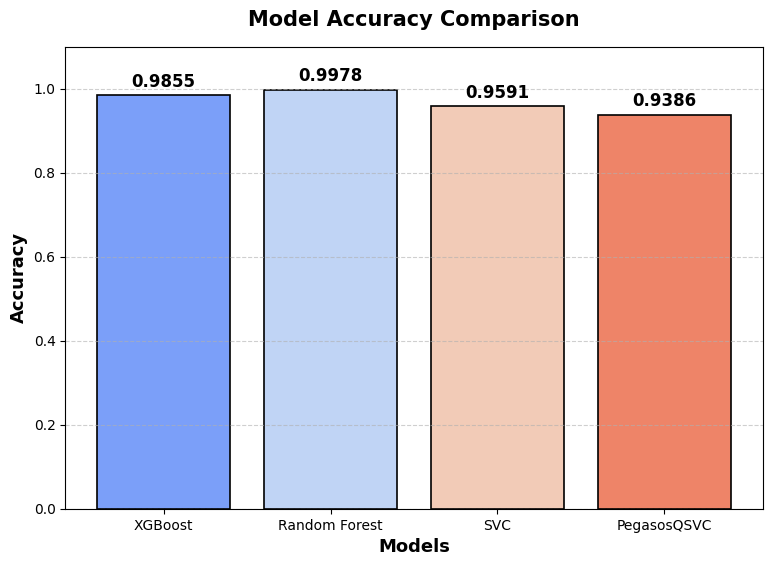

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy values for different models
accuracies = {
    "XGBoost": xgb_accuracy,
    "Random Forest": rf_accuracy,
    "SVC": accuracy,
    "PegasosQSVC": pqsvc_acc
}

# Define colors using a better palette
colors = sns.color_palette("coolwarm", len(accuracies))

# Plot the bar graph
plt.figure(figsize=(9, 6))
bars = plt.bar(accuracies.keys(), accuracies.values(), color=colors, edgecolor='black', linewidth=1.2)

# Add labels and title
plt.xlabel("Models", fontsize=13, fontweight="bold")
plt.ylabel("Accuracy", fontsize=13, fontweight="bold")
plt.title("Model Accuracy Comparison", fontsize=15, fontweight="bold", pad=15)

# Add values on top of bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.4f}", ha='center', fontsize=12, fontweight="bold")

# Adjust y-axis limits and add a subtle grid
plt.ylim(0, 1.1)  # Slightly above 1 to give spacing
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.show()